# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


Os dados usados foram tratados posteriormente - balanceamento de classes, transformação de variáveis categóricas e separação de base de treino e teste.
Nesse projeto o método de árvore de decisão foi aplicado afim de criar modelos de previsões do score de crédito.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

### 1) Carregar e verificar as bases de treino (X e y) e teste (X e y).
#### Carregando as bases de treino e teste.

In [15]:
X_test = pd.read_csv("X_test.csv", delimiter=',')
X_train = pd.read_csv("X_train_balanced.csv", delimiter=',')
y_test = pd.read_csv("y_test.csv", delimiter=',')
y_train = pd.read_csv("y_train_balanced.csv", delimiter=',')

#### Verificação das bases
Apesar de cada base estar separada em X (variáveis explicativas) e y (variáveis rótulos/a serem previstas), elas devem ter o mesmo tamanho pois, para cada conjunto (linha) de X é preciso ter um rótulo y associado.
Além disso, as bases de X não devem conter a variável rótulo/a ser previsa.

In [17]:
print( "X teste reprovado" if 'Credit Score' in X_test.columns else "X teste não contém a variável rótulo.")
print( "X treino reprovado" if 'Credit Score' in X_train.columns else "X treino não contém a variável rótulo.")
print("X e y teste possuem o mesmo tamanho." if len(y_test)==len(X_test) else "X e y reprovados.")
print("X e y treino possuem o mesmo tamanho." if len(y_train)==len(X_train) else "X e y reprovados.")

X teste não contém a variável rótulo.
X treino não contém a variável rótulo.
X e y teste possuem o mesmo tamanho.
X e y treino possuem o mesmo tamanho.


#### Verificar o balanceamento das variáveis rótulos da base de treino.
É preciso que o modelo seja treinado com uma base que contenha o mesmo número de dados de cada opção de variável a ser prevista. Caso contrário, haverá, especialmente para o modelo naive, um desequilíbrio no cálculo da probabilidade de ocorrência de cada y. Isso ocorre por que, resumidamente, se uma das opções for mais numerosa que outra, ela se torna mais frequente e, logo, mais provável que ela ocorra.

In [18]:
train_balance = y_train.value_counts()
n0=train_balance[0]

for n in train_balance.items():
    #print(n0,n[1])
    #print(n0==n[1]) 
    print( "Balanceado" if n0==n[1] else "Desbalanceado")
    n0=n[1]

Balanceado
Balanceado
Balanceado


C:\Users\marina.freitas\AppData\Local\Temp\ipykernel_12476\2871665982.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  n0=train_balance[0]


# 2) Descrição do passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

# Bilioteca que é a implementação de árvores de decisão disponível no scikit-learn.
# 'criterion' define o critério para medir a qualidade da divisão (usando o índice de Gini neste caso)
# 'random_state' define a semente aleatória para garantir a reprodutibilidade dos resultados
O random_state permite que você controle essa aleatoriedade. Quando você fornece um valor específico para random_state, o algoritmo realizará todas as operações aleatórias exatamente da mesma maneira sempre que for executado com o mesmo random_state. Isso é útil para garantir a consistência dos resultados, especialmente quando você está comparando diferentes modelos ou executando experimentos de forma repetida.
para metros daa arvore de decisão, escolher, asism como geni e random state

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [34]:
from sklearn.tree import DecisionTreeClassifier 


arvore_01 = DecisionTreeClassifier (criterion = 'gini', random_state = 0)
arvore_01.fit(X_train, y_train)

# Aprimorando a exibição dos resultados
params = arvore_01.get_params()

parametros_descricao = [
    "ccp_alpha:\n Este é o parâmetro de poda. Controla o custo de complexidade-complexidade poda (CCP). Valores maiores de ccp_alpha incentivam a poda, o que pode levar a uma árvore mais simples, evitando o overfitting.",
    "class_weight:\n Peso associado às classes. Pode ser usado para lidar com conjuntos de dados desequilibrados, dando mais peso às classes menos representadas.",
    "criterion:\n O critério usado para medir a qualidade da divisão em cada nó da árvore. 'gini' para índice de Gini ou 'entropy' para ganho de informação.",
    "max_depth:\n A profundidade máxima da árvore. Controla a profundidade máxima que a árvore pode atingir. Limitar a profundidade pode ajudar a evitar overfitting.",
    "max_features:\n O número máximo de características a serem consideradas ao procurar a melhor divisão. Pode ser um número ou uma proporção das características.",
    "max_leaf_nodes:\n O número máximo de folhas na árvore. Limita o crescimento da árvore, ajudando a evitar overfitting.",
    "min_impurity_decrease:\n Um nó será dividido se a divisão resultante diminuir a impureza ponderada por pelo menos esse valor.",
    "min_samples_leaf:\n O número mínimo de amostras que deve estar presente em uma folha. Garante que cada folha da árvore tenha pelo menos esse número de amostras, ajudando a evitar que a árvore crie folhas com poucos dados e, assim, reduza o risco de overfitting.",
    "min_samples_split:\n O número mínimo de amostras necessárias para dividir um nó interno. Controla o número mínimo de amostras necessárias para realizar uma divisão.",
    "min_weight_fraction_leaf:\n A fração ponderada do número total de amostras que deve ser em uma folha.",
    'monotonic_cst',
    "random_state:\n O estado aleatório usado para dividir os dados em conjuntos de treinamento e teste. Garante reprodutibilidade dos resultados.",
    "splitter:\n A estratégia usada para escolher a divisão em cada nó. 'best' para escolher a melhor divisão ou 'random' para escolher uma divisão aleatória entre as melhores divisões."
]
i=0
for chave, valor in params.items():
    print(parametros_descricao[i])
    print(f"   Valor = {valor}")
    i+=1

ccp_alpha:
 Este é o parâmetro de poda. Controla o custo de complexidade-complexidade poda (CCP). Valores maiores de ccp_alpha incentivam a poda, o que pode levar a uma árvore mais simples, evitando o overfitting.
   Valor = 0.0
class_weight:
 Peso associado às classes. Pode ser usado para lidar com conjuntos de dados desequilibrados, dando mais peso às classes menos representadas.
   Valor = None
criterion:
 O critério usado para medir a qualidade da divisão em cada nó da árvore. 'gini' para índice de Gini ou 'entropy' para ganho de informação.
   Valor = gini
max_depth:
 A profundidade máxima da árvore. Controla a profundidade máxima que a árvore pode atingir. Limitar a profundidade pode ajudar a evitar overfitting.
   Valor = None
max_features:
 O número máximo de características a serem consideradas ao procurar a melhor divisão. Pode ser um número ou uma proporção das características.
   Valor = None
max_leaf_nodes:
 O número máximo de folhas na árvore. Limita o crescimento da árvo

In [58]:
print("Comparação entre os 10 primeiros valores de previsão e os valores reais da base de treino:")
previsoes = arvore_01.predict(X_train)

for l in range(10):
    print(f"Valor previsto = {previsoes[l]} ---- Valor real = {y_train.values[l]} ")


Comparação entre os 10 primeiros valores de previsão e os valores reais da base de treino:
Valor previsto = Average ---- Valor real = ['Average'] 
Valor previsto = Low ---- Valor real = ['Low'] 
Valor previsto = Average ---- Valor real = ['Average'] 
Valor previsto = Average ---- Valor real = ['Average'] 
Valor previsto = Average ---- Valor real = ['Average'] 
Valor previsto = High ---- Valor real = ['High'] 
Valor previsto = High ---- Valor real = ['High'] 
Valor previsto = High ---- Valor real = ['High'] 
Valor previsto = Average ---- Valor real = ['Average'] 
Valor previsto = High ---- Valor real = ['High'] 


# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [64]:
from sklearn.metrics import accuracy_score, classification_report
previsoes = arvore_01.predict(X_test)
#acuracia = accuracy_score(y_test, previsoes)
relatorio = classification_report(y_test, previsoes)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

     Average       1.00      1.00      1.00         6
        High       1.00      1.00      1.00        29
         Low       1.00      1.00      1.00         6

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41



Os resultados indicam que o modelo está muito bem adaptado aos dados. Isso pode ser bom, mas pode ser ruim. É possível que o motivo do resultado ser um é em decorrência do overfitting, quando um modelo se cnstrói perfeitamente para uma base de dados específica, como se decorrasse os números. A sugestão é que esse modelo seja aplicado a bancos de dados diferentes e os trestes sejam reanalisados.

Esse resultado indica que a matriz de confusão deve destacar apenas os blocos de verdadeiros e falsos.

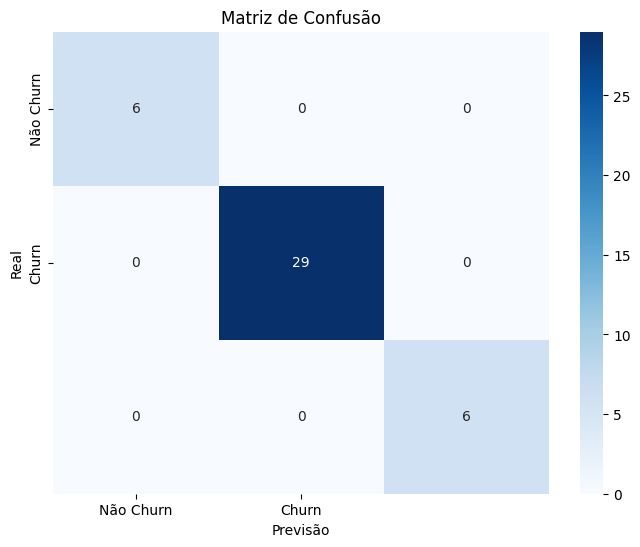

In [65]:
matriz_confusao = confusion_matrix(y_test, previsoes)

# Plotando a matriz de confusão como um mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Não Churn', 'Churn'],
            yticklabels=['Não Churn', 'Churn'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

#### Verificação das bases
Apesar de cada base estar separada em X (variáveis explicativas) e y (variáveis rótulos/a serem previstas), elas devem ter o mesmo tamanho pois, para cada conjunto (linha) de X é preciso ter um rótulo y associado.
Além disso, as bases de X não devem conter a variável rótulo/a ser previsa.

In [ ]:
#seu código aqui

# 6) Identifique as 2 principais features do modelo.


In [ ]:
#seu código aqui

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [ ]:
#seu código aqui

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

In [ ]:
#Seu texto aqui